# Phase 1: LightGBM + Group Imputation + Missing Flags

Mejoras sobre el baseline:
1. **LightGBM** en lugar de RandomForest
2. **Imputación por grupo** (`Position_Type`) en vez de media global
3. **Missing flags** — columnas binarias que indican si el valor original era NaN

Métrica objetivo: AUC (Area Under ROC Curve)

## 1. Setup

In [1]:
import numpy as np
import pandas as pd
import lightgbm as lgb
import matplotlib.pyplot as plt
import warnings
from pathlib import Path
from datetime import datetime
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import LabelEncoder

warnings.filterwarnings('ignore')

SEED = 42
N_FOLDS = 5

INPUT_PATH  = Path('/Users/haroldlagares/Downloads/competition/input')
RESULTS_DIR = Path('/Users/haroldlagares/Downloads/competition/results')
RESULTS_DIR.mkdir(exist_ok=True)

print('LightGBM version:', lgb.__version__)

LightGBM version: 4.6.0


## 2. Load Data

In [2]:
train = pd.read_csv(INPUT_PATH / 'train.csv')
test  = pd.read_csv(INPUT_PATH / 'test.csv')
sample_sub = pd.read_csv(INPUT_PATH / 'sample_submission.csv')

print('Train:', train.shape)
print('Test: ', test.shape)
train.head(3)

Train: (2781, 16)
Test:  (696, 15)


,Id,Year,Age,School,Height,Weight,Sprint_40yd,Vertical_Jump,Bench_Press_Reps,Broad_Jump,Agility_3cone,Shuttle,Player_Type,Position_Type,Position,Drafted
0,0,2011,21.0,Lehigh,1.9050,140.160042,5.39,59.69,29.0,251.46,7.91,4.94,offense,offensive_lineman,OG,1.0
1,1,2011,24.0,Abilene Christian,1.8288,87.089735,4.31,101.60,16.0,332.74,NaN,NaN,offense,backs_receivers,WR,1.0
2,2,2018,21.0,Colorado St.,1.8542,92.986436,4.51,91.44,10.0,309.88,6.95,4.37,offense,backs_receivers,WR,1.0


## 3. Missing Flags

Creamos una columna binaria por cada feature con NaN. La ausencia de dato puede ser señal en sí misma: los jugadores que no realizaron ciertos tests tienen distintas tasas de draft.

In [3]:
# Columnas con valores nulos en train
NULL_COLS = ['Age', 'Sprint_40yd', 'Vertical_Jump', 'Bench_Press_Reps',
             'Broad_Jump', 'Agility_3cone', 'Shuttle']

for col in NULL_COLS:
    flag_name = f'missing_{col}'
    train[flag_name] = train[col].isna().astype(np.int8)
    test[flag_name]  = test[col].isna().astype(np.int8)

# Verificar señal de los flags
print('Draft rate según presencia de dato (train):')
for col in NULL_COLS:
    flag = f'missing_{col}'
    rates = train.groupby(flag)['Drafted'].mean()
    diff = rates.get(1, 0) - rates.get(0, 0)
    print(f'  {col:20s} -> presente: {rates.get(0,0):.3f} | ausente: {rates.get(1,0):.3f} | diff: {diff:+.3f}')

Draft rate según presencia de dato (train):
  Age                  -> presente: 0.765 | ausente: 0.018 | diff: -0.747
  Sprint_40yd          -> presente: 0.652 | ausente: 0.586 | diff: -0.066
  Vertical_Jump        -> presente: 0.664 | ausente: 0.585 | diff: -0.079
  Bench_Press_Reps     -> presente: 0.665 | ausente: 0.602 | diff: -0.063
  Broad_Jump           -> presente: 0.663 | ausente: 0.594 | diff: -0.069
  Agility_3cone        -> presente: 0.671 | ausente: 0.605 | diff: -0.066
  Shuttle              -> presente: 0.671 | ausente: 0.601 | diff: -0.071


## 4. Group Imputation by Position_Type

Imputamos con la **mediana por `Position_Type`** en lugar de la media global. Un kicker y un lineman tienen métricas completamente distintas — mezclar sus medias introduce ruido.

In [4]:
# Calcular medianas por Position_Type usando solo train (para no filtrar info de test)
group_medians = train.groupby('Position_Type')[NULL_COLS].median()
print('Medianas por Position_Type:')
print(group_medians.round(2))

Medianas por Position_Type:
                     Age  Sprint_40yd  Vertical_Jump  Bench_Press_Reps  \
Position_Type                                                            
backs_receivers     22.0         4.58          86.36              17.0   
defensive_back      22.0         4.51          90.17              15.0   
defensive_lineman   22.0         4.94          78.74              26.0   
kicking_specialist  22.0         4.93          80.01              19.0   
line_backer         22.0         4.71          85.09              22.0   
offensive_lineman   22.0         5.24          69.85              25.0   
other_special       22.0         5.00          73.66              15.5   

                    Broad_Jump  Agility_3cone  Shuttle  
Position_Type                                           
backs_receivers         299.72           7.03     4.28  
defensive_back          307.34           6.93     4.18  
defensive_lineman       279.40           7.46     4.55  
kicking_specialist  

In [5]:
def group_impute(df, group_col, cols, medians):
    """Imputa `cols` usando la mediana del grupo `group_col`.
    Si el grupo no está en medians, usa la mediana global de medians.
    """
    df = df.copy()
    global_median = medians.median()  # fallback
    for idx, row in df.iterrows():
        grp = row[group_col]
        for col in cols:
            if pd.isna(row[col]):
                if grp in medians.index:
                    df.at[idx, col] = medians.loc[grp, col]
                else:
                    df.at[idx, col] = global_median[col]
    return df

# Aplicar imputación
train = group_impute(train, 'Position_Type', NULL_COLS, group_medians)
test  = group_impute(test,  'Position_Type', NULL_COLS, group_medians)

# Verificar que no quedan nulos en las columnas imputadas
remaining = train[NULL_COLS].isnull().sum().sum()
print(f'Nulos restantes tras imputación: {remaining}')

Nulos restantes tras imputación: 0


## 5. Feature Engineering — BMI

In [6]:
for df in [train, test]:
    df['BMI'] = df['Weight'] / (df['Height'] ** 2)

print('BMI agregado. Stats:')
print(train['BMI'].describe().round(3))

BMI agregado. Stats:
count    2781.000
mean       31.021
std         4.410
min        21.610
25%        27.442
50%        30.081
75%        33.872
max        44.680
Name: BMI, dtype: float64


## 6. Encoding de Categóricas

- `School`: descartada (236 únicos — se abordará con target encoding en Fase 2)
- `Player_Type`, `Position_Type`, `Position`: LabelEncoder

In [7]:
CAT_COLS = ['Player_Type', 'Position_Type', 'Position']

label_encoders = {}
for col in CAT_COLS:
    le = LabelEncoder()
    # Fit en train+test para evitar unseen labels
    le.fit(pd.concat([train[col], test[col]], ignore_index=True).astype(str))
    train[col] = le.transform(train[col].astype(str))
    test[col]  = le.transform(test[col].astype(str))
    label_encoders[col] = le

# Descartar columnas no usadas
DROP_COLS = ['Id', 'School']
train.drop(columns=DROP_COLS, inplace=True)
test.drop(columns=DROP_COLS, inplace=True)

print('Features finales:', [c for c in train.columns if c != 'Drafted'])
print('Total features:', train.shape[1] - 1)

Features finales: ['Year', 'Age', 'Height', 'Weight', 'Sprint_40yd', 'Vertical_Jump', 'Bench_Press_Reps', 'Broad_Jump', 'Agility_3cone', 'Shuttle', 'Player_Type', 'Position_Type', 'Position', 'missing_Age', 'missing_Sprint_40yd', 'missing_Vertical_Jump', 'missing_Bench_Press_Reps', 'missing_Broad_Jump', 'missing_Agility_3cone', 'missing_Shuttle', 'BMI']
Total features: 21


## 7. LightGBM con StratifiedKFold

LightGBM con parámetros conservadores para esta primera fase. Usamos early stopping por fold para evitar overfitting.

In [8]:
FEATURE_COLS = [c for c in train.columns if c != 'Drafted']
TARGET_COL   = 'Drafted'

X = train[FEATURE_COLS].values
y = train[TARGET_COL].values
X_test = test[FEATURE_COLS].values

print(f'X shape: {X.shape}, X_test shape: {X_test.shape}')

X shape: (2781, 21), X_test shape: (696, 21)


In [9]:
lgb_params = {
    'objective':        'binary',
    'metric':           'auc',
    'learning_rate':    0.05,
    'num_leaves':       63,
    'max_depth':        -1,
    'min_child_samples': 20,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq':     5,
    'reg_alpha':        0.1,
    'reg_lambda':       0.1,
    'verbose':          -1,
    'seed':             SEED,
}

skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)

oof_preds  = np.zeros(len(X))
test_preds = np.zeros(len(X_test))
fold_scores = []

feature_importances = pd.DataFrame({'feature': FEATURE_COLS})

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
    X_tr, X_val = X[train_idx], X[val_idx]
    y_tr, y_val = y[train_idx], y[val_idx]

    dtrain = lgb.Dataset(X_tr, label=y_tr, feature_name=FEATURE_COLS)
    dval   = lgb.Dataset(X_val, label=y_val, feature_name=FEATURE_COLS, reference=dtrain)

    model = lgb.train(
        lgb_params,
        dtrain,
        num_boost_round=1000,
        valid_sets=[dval],
        callbacks=[
            lgb.early_stopping(stopping_rounds=50, verbose=False),
            lgb.log_evaluation(period=-1),
        ],
    )

    val_pred = model.predict(X_val)
    fold_auc = roc_auc_score(y_val, val_pred)
    fold_scores.append(fold_auc)

    oof_preds[val_idx] = val_pred
    test_preds += model.predict(X_test) / N_FOLDS

    feature_importances[f'fold_{fold}'] = model.feature_importance(importance_type='gain')

    print(f'Fold {fold} | AUC: {fold_auc:.5f} | Best iter: {model.best_iteration}')

oof_auc = roc_auc_score(y, oof_preds)
print(f'\nOOF AUC: {oof_auc:.5f}  (mean folds: {np.mean(fold_scores):.5f} ± {np.std(fold_scores):.5f})')

Fold 1 | AUC: 0.80681 | Best iter: 47


Fold 2 | AUC: 0.83990 | Best iter: 55


Fold 3 | AUC: 0.83992 | Best iter: 26


Fold 4 | AUC: 0.79566 | Best iter: 34


Fold 5 | AUC: 0.83379 | Best iter: 38

OOF AUC: 0.82056  (mean folds: 0.82322 ± 0.01842)


## 8. Feature Importance

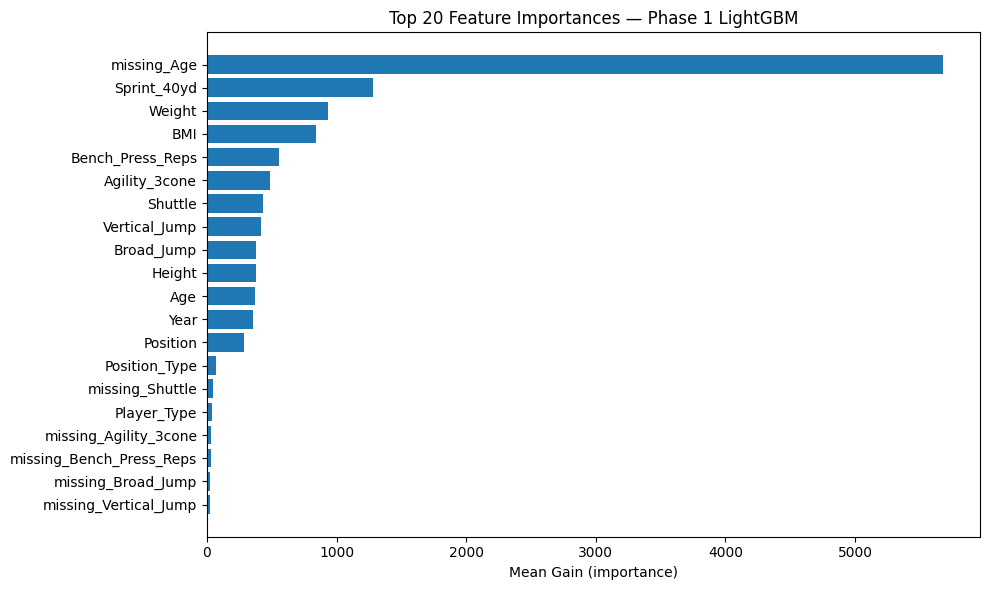

                 feature   mean_gain
             missing_Age 5680.353249
             Sprint_40yd 1281.814332
                  Weight  935.638553
                     BMI  839.558365
        Bench_Press_Reps  558.527340
           Agility_3cone  484.651743
                 Shuttle  434.287602
           Vertical_Jump  413.969476
              Broad_Jump  381.335475
                  Height  379.389353
                     Age  366.808627
                    Year  355.662605
                Position  288.082410
           Position_Type   71.587616
         missing_Shuttle   46.257496
             Player_Type   37.708835
   missing_Agility_3cone   29.539668
missing_Bench_Press_Reps   27.358364
      missing_Broad_Jump   25.607323
   missing_Vertical_Jump   25.481243
     missing_Sprint_40yd    3.688276


In [10]:
fold_cols = [c for c in feature_importances.columns if c.startswith('fold_')]
feature_importances['mean_gain'] = feature_importances[fold_cols].mean(axis=1)
feature_importances = feature_importances.sort_values('mean_gain', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(feature_importances['feature'][:20], feature_importances['mean_gain'][:20])
plt.xlabel('Mean Gain (importance)')
plt.title('Top 20 Feature Importances — Phase 1 LightGBM')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print(feature_importances[['feature', 'mean_gain']].to_string(index=False))

## 9. Guardar Submission

In [11]:
timestamp = datetime.now().strftime('%Y-%m-%d_%H-%M-%S')
submission_path = RESULTS_DIR / f'submission_phase1_{timestamp}.csv'

submission = pd.read_csv(INPUT_PATH / 'sample_submission.csv')
submission['Drafted'] = test_preds
submission.to_csv(submission_path, index=False)

print(f'Submission guardado en: {submission_path}')
print(f'OOF AUC: {oof_auc:.5f}')
print(submission.head())

Submission guardado en: /Users/haroldlagares/Downloads/competition/results/submission_phase1_2026-05-14_18-06-14.csv
OOF AUC: 0.82056
     Id   Drafted
0  2781  0.719397
1  2782  0.828260
2  2783  0.837427
3  2784  0.834660
4  2785  0.735634
